<a href="https://colab.research.google.com/github/Alberto2804/ProyectoIA_Salud/blob/main/datos_costes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

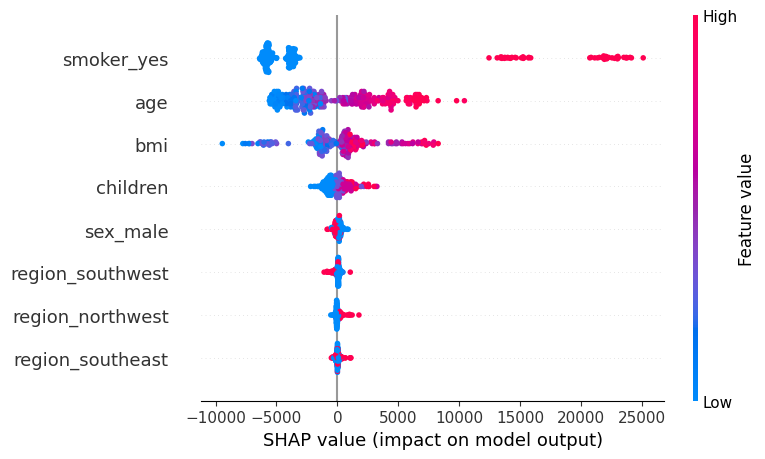

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import shap

df_costes = pd.read_csv('datos_costes.csv')

df_numerico = pd.get_dummies(df_costes, drop_first=True)


X = df_numerico.drop('charges', axis=1)
y = df_numerico['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


modelo_regresion = RandomForestRegressor(random_state=42)
modelo_regresion.fit(X_train, y_train)


explainer = shap.TreeExplainer(modelo_regresion)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)